# Dataset description
## Top five deaths for men and women in 2025

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/defunciones)

# Code
## imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
import matplotlib.ticker as mtick

BASE_DIR = Path.cwd().parent.parent
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [2]:
path = "data/departamento_muerte.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,1,2,4,5])
logo = plt.imread(logo_path)

## Clean data

In [3]:
df_f = df[
    (df["Fecha"].eq(2025)) &
    (df["departamento"].str.lower().str.startswith("total"))
]

df_f.drop(columns=["Fecha", "departamento"], inplace=True)
df_f

def top_5_causes(df: pd.DataFrame, column: str) -> pd.DataFrame:
    top_5 = df.nlargest(5, column)[["causa", column]]
     
    renamed = top_5.rename(columns={column: "total"})
    
    sorted_data = renamed.sort_values(by="total", ascending=True)
    
    return sorted_data

men = top_5_causes(df_f, "Total_Hombres")
women = top_5_causes(df_f, "Total_Mujeres")

men_translations = {
    "090 Accidentes de transporte de motor y secuelas": "Motor transport\naccidents and sequelae",
    "055 Enfermedades cerebrovasculares": "Cerebrovascular diseases",
    "060 Enfermedades crónicas de las vías respiratorias inferiores": "Chronic lower\nrespiratory diseases",
    "101 Agresiones (homicidios) y secuelas": "Assaults (homicides)\nand sequelae",
    "051 Enfermedades isquémicas del corazón": "Ischemic heart\ndiseases"
}

women_translations = {
    "050 Enfermedades hipertensivas": "Hypertensive diseases",
    "059 Neumonía": "Pneumonia",
    "055 Enfermedades cerebrovasculares": "Cerebrovascular diseases",
    "060 Enfermedades crónicas de las vías respiratorias inferiores": "Chronic lower\nrespiratory diseases",
    "051 Enfermedades isquémicas del corazón": "Ischemic heart\ndiseases"
}

## Plor

In [4]:
def plot(df: pd.DataFrame, gender: str, terms: dict) -> None:
    df["causa"] = df["causa"].map(terms)
    color = "#4a90e2" if gender == "Men" else "#FF6B9D"
    background = "#F4F1EA"

    fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
    fig.patch.set_facecolor(background)
    ax.patch.set_facecolor(background)

    plt.barh(df["causa"], df["total"], color=color)

    for side in ["top", "bottom", "left", "right"]:
        plt.gca().spines[side].set_visible(False)

    for axis in ["y", "x"]:
        plt.tick_params(axis=axis, length=0)

    plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    plt.xlabel("Deaths", labelpad=10, fontsize=10)

    fig_text(
        x=0.125, y=0.96,
        s=f"What Colombian <{gender}> Actually Die From",
        highlight_textprops=[{"color": color, "weight": "bold"}],
        fontsize=15
    )

    fig_text(
        x=0.125, y=0.92,
        s="Top 5 causes of death - Colombia, 2025",
        fontsize=12
    )

    fig_text(
        0.125, 0.05, 
        "Source: DANE.\n", 
        fontsize=10, color="gray",
    )

    imagebox = OffsetImage(logo, zoom=0.4)

    ab = AnnotationBbox(imagebox, xy=(0.9, 0.035), xycoords="figure fraction",
                        frameon=False, pad=0)

    plt.gca().add_artist(ab)

    plt.show()

### Chart Men

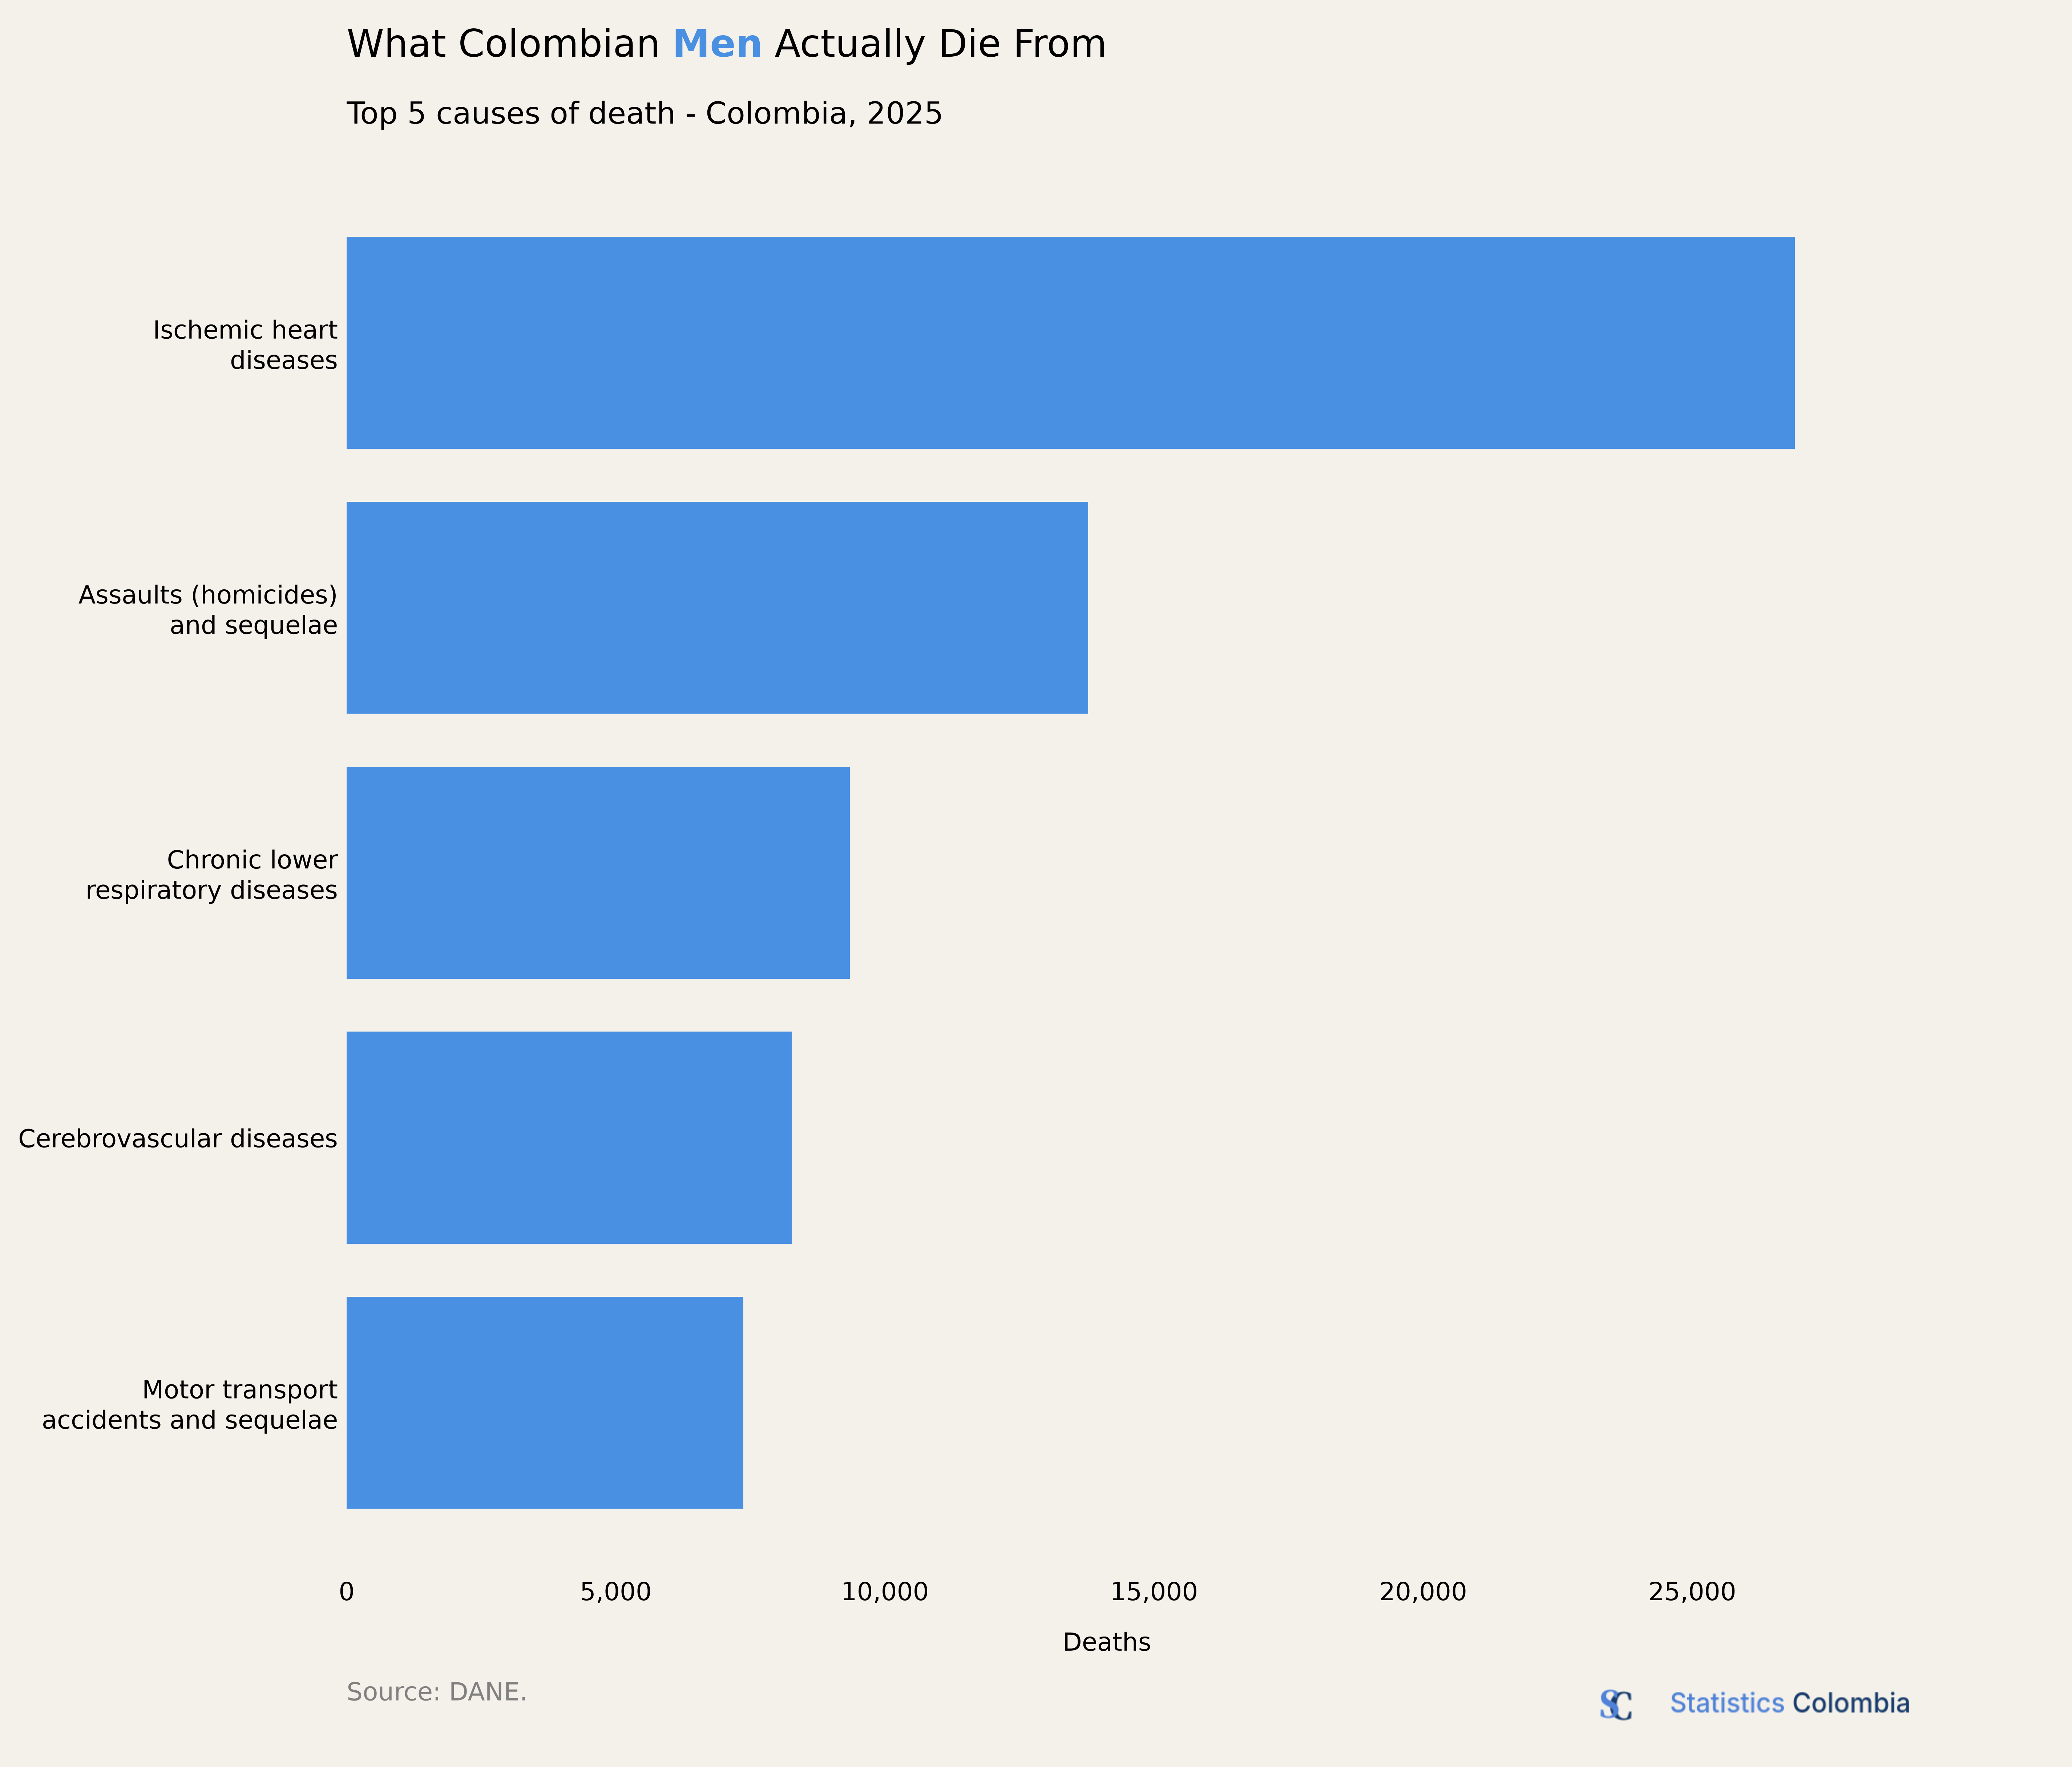

In [5]:
plot(men, "Men", men_translations)

### Chart Women

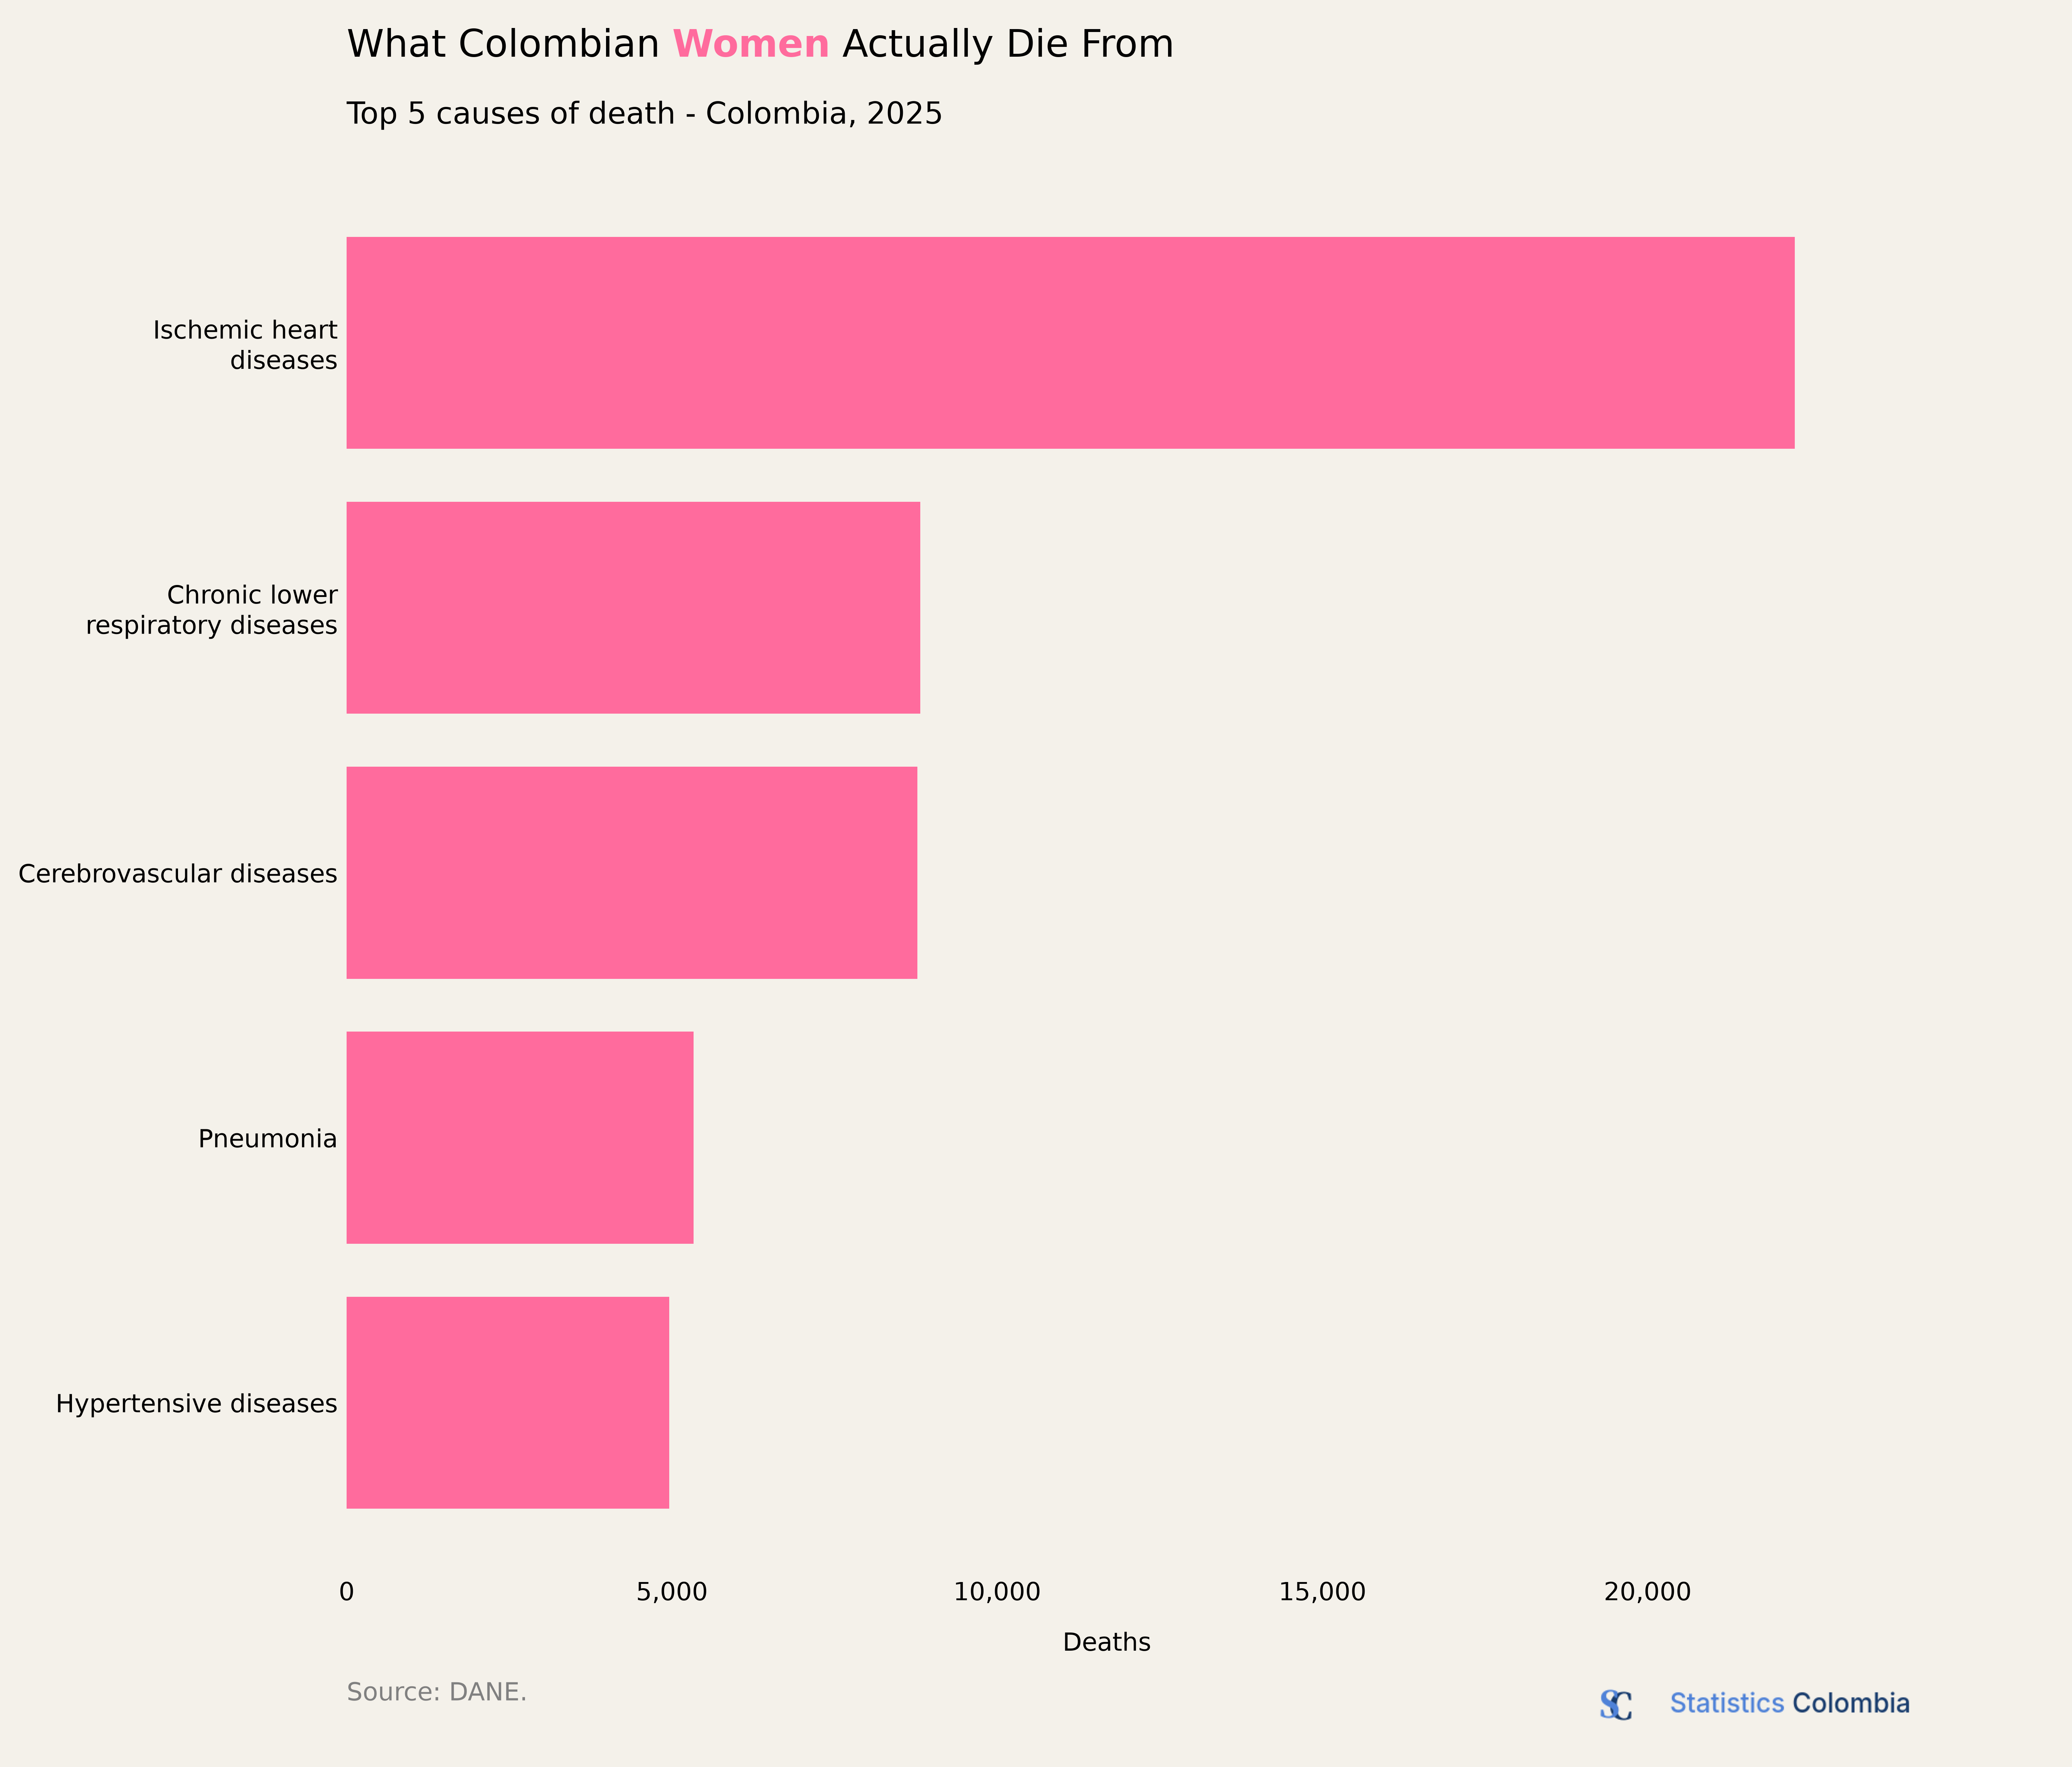

In [6]:
plot(women, "Women", women_translations)